# Продуктовая аналитика и A/B-тестирование в цифровом маркетплейсе
## Оценка результатов эксперимента с новой AI-моделью рекомендаций

**Команда: К недрам Чили**


In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from statsmodels.stats.multitest import multipletests
import warnings
warnings.filterwarnings("ignore")

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'

## Загрузка данных и первичный аудит представленного датасета

Датасет состоит из 10 таблиц: пользователи, распределение по группам эксперимента,
сессии, показы рекомендаций, клики, заказы, каталог товаров, продавцы, подписки
Premium и обращения в поддержку.

Ниже — первичный обзор структуры каждой таблицы, на основе которого
в следующем разделе проведём аудит качества данных.

In [3]:
np.random.seed(42)

def load_data(data):
  tables = {}
  names = ["users", "experiment_assignments", "sessions", "impressions",
              "clicks", "orders", "products", "sellers",
              "premium_subscriptions", "support_tickets"]
  for name in names:
    tables[name] = pd.read_csv(f"{data}/{name}.csv")
  return tables

tables = load_data("data")
users, exp, sessions, impressions, clicks, orders, products, sellers, premium, tickets = (
     tables["users"], tables["experiment_assignments"], tables["sessions"],
     tables["impressions"], tables["clicks"], tables["orders"], tables["products"],
     tables["sellers"], tables["premium_subscriptions"], tables["support_tickets"]
)

In [4]:
for key in tables.keys():
    print(tables[f"{key}"].info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   user_id            50000 non-null  object
 1   registration_date  50000 non-null  object
 2   region             50000 non-null  object
 3   device             50000 non-null  object
 4   age_group          50000 non-null  object
 5   traffic_source     50000 non-null  object
 6   is_premium         50000 non-null  int64 
 7   is_bot_candidate   50000 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 3.1+ MB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50300 entries, 0 to 50299
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   assignment_id      50300 non-null  object
 1   user_id            50300 non-null  object
 2   experiment_name    50300 non-null  object
 3   experiment_group   

**Наблюдения по таблице `orders`:**
- 14 колонок, 7407 заказов,
- Пропуски в `delivery_fee_rub` (303 из 7407, ~4%) — требуют проверки, случайны
  ли они
- `return_date` заполнен только для 462 строк — ожидаемо (только возвращённые
  заказы), проверим согласованность с `is_returned`

**Наблюдения по схеме в целом:**
- `experiment_assignments` содержит 50300 записей, при 50000 пользователей в
  `users` — потенциально несколько экспериментов в одной таблице или дубли,
  нужно проверить `experiment_name`
- `experiment_group` присутствует и в `experiment_assignments`, и в `sessions` —
  можно свериться на консистентность
- В `users` есть флаг `is_bot_candidate`, в `impressions` — `is_duplicate_event`:
  оба нужно учесть при очистке перед расчётом метрик

## 1. Проверка качества данных

Проведём аудит по пяти направлениям: пропуски, дубли, корректность распределения
по группам эксперимента, аномалии, и в конце — свод найденных проблем с подходом
к их обработке.

In [5]:
def audit_table(df, name, pk=None):
    print(f"\n{'='*60}\n{name}\n{'='*60}")
    print(f"Строк: {len(df)}, колонок: {df.shape[1]}")

    na = df.isna().sum()
    na = na[na > 0]
    if len(na):
        na_pct = (na / len(df) * 100).round(2)
        print("\nПропуски:")
        print(pd.DataFrame({"count": na, "pct": na_pct}))
    else:
        print("\nПропусков нет")

    if pk:
        dup = df.duplicated(subset=pk).sum()
        print(f"\nДубликатов по PK ({pk}): {dup}")
    dup_full = df.duplicated().sum()
    print(f"Полных дубликатов строк: {dup_full}")
    return {"table": name, "n_rows": len(df), "n_na_cols": len(na), "pk_dups": dup if pk else None}


tables_pk = {
    "users": (users, "user_id"),
    "experiment_assignments": (exp, "assignment_id"),
    "sessions": (sessions, "session_id"),
    "impressions": (impressions, "impression_id"),
    "clicks": (clicks, "click_id"),
    "orders": (orders, "order_id"),
    "products": (products, "product_id"),
    "sellers": (sellers, "seller_id"),
    "premium_subscriptions": (premium, None),
    "support_tickets": (tickets, "ticket_id"),
}

audit_summary = []
for label, (df, pk) in tables_pk.items():
    audit_summary.append(audit_table(df, label, pk=pk))

audit_summary_df = pd.DataFrame(audit_summary)
audit_summary_df


users
Строк: 50000, колонок: 8

Пропусков нет

Дубликатов по PK (user_id): 0
Полных дубликатов строк: 0

experiment_assignments
Строк: 50300, колонок: 6

Пропусков нет

Дубликатов по PK (assignment_id): 0
Полных дубликатов строк: 0

sessions
Строк: 164739, колонок: 9

Пропусков нет

Дубликатов по PK (session_id): 0
Полных дубликатов строк: 0

impressions
Строк: 1066434, колонок: 9

Пропусков нет

Дубликатов по PK (impression_id): 0
Полных дубликатов строк: 0

clicks
Строк: 91266, колонок: 7

Пропусков нет

Дубликатов по PK (click_id): 0
Полных дубликатов строк: 0

orders
Строк: 7407, колонок: 14

Пропуски:
                  count    pct
delivery_fee_rub    303   4.09
return_date        6945  93.76

Дубликатов по PK (order_id): 0
Полных дубликатов строк: 0

products
Строк: 4500, колонок: 8

Пропусков нет

Дубликатов по PK (product_id): 0
Полных дубликатов строк: 0

sellers
Строк: 700, колонок: 5

Пропусков нет

Дубликатов по PK (seller_id): 0
Полных дубликатов строк: 0

premium_subscri

,table,n_rows,n_na_cols,pk_dups
0,users,50000,0,0.0
1,experiment_assignments,50300,0,0.0
2,sessions,164739,0,0.0
3,impressions,1066434,0,0.0
4,clicks,91266,0,0.0
5,orders,7407,2,0.0
6,products,4500,0,0.0
7,sellers,700,0,0.0
8,premium_subscriptions,9127,0,NaN
9,support_tickets,337,0,0.0


### 1.1 Корректность распределения пользователей между группами

Проверяем: сколько экспериментов в данных, нет ли контаминации (юзер в обеих
группах), SRM (Sample Ratio Mismatch), баланс ковариат между control/test.

In [6]:
print(exp["experiment_name"].value_counts())
print()
print(exp["experiment_group"].value_counts())
print()
print(exp["assignment_source"].value_counts())

experiment_name
ai_recommendations_homepage    50300
Name: count, dtype: int64

experiment_group
test       25326
control    24974
Name: count, dtype: int64

assignment_source
assignment_service        50000
assignment_service_bug      300
Name: count, dtype: int64


In [7]:
buggy_users = exp[exp["assignment_source"] == "assignment_service_bug"]["user_id"].unique()
print(f"Пользователей, затронутых багом assignment_service_bug: {len(buggy_users)}")
check = exp[exp["user_id"].isin(buggy_users)].groupby("user_id")["experiment_group"].nunique()
print(f"Из них реально в разных группах A/B тестирования: {(check > 1).sum()} из {len(buggy_users)}")

Пользователей, затронутых багом assignment_service_bug: 300
Из них реально в разных группах A/B тестирования: 300 из 300


**Найдена критическая проблема: contamination групп эксперимента.**

Часть пользователей получила назначение в ОБЕ группы (`control` и `test`)
из-за бага сервиса присвоения (поле `assignment_source = "assignment_service_bug"`,
задокументировано в самих данных). Эти пользователи видели обе версии
рекомендательной системы, что нарушает предпосылку независимости групп.

**Решение:** исключить всех затронутых пользователей из дальнейшего анализа —
их поведение нельзя однозначно приписать ни одной из групп.

In [8]:
exp_clean = exp[~exp["user_id"].isin(buggy_users)].copy()

print(f"Было: {len(exp)} записей, {exp['user_id'].nunique()} юзеров")
print(f"Стало: {len(exp_clean)} записей, {exp_clean['user_id'].nunique()} юзеров")
print(f"Дублей user_id после чистки: {exp_clean['user_id'].duplicated().sum()}")

Было: 50300 записей, 50000 юзеров
Стало: 49700 записей, 49700 юзеров
Дублей user_id после чистки: 0


### SRM-тест на очищенных данных
Проведём SRM-тест на очищенных данных, чтобы определить есть ли перекос по сплиту
пользователей между control и test группами

In [9]:
def check_srm(exp_assignments, group_col="experiment_group", expected_ratio=0.5, alpha=0.01):
    counts = exp_assignments[group_col].value_counts()
    n_total = counts.sum()
    observed = counts.values
    expected = np.array([n_total * expected_ratio, n_total * (1 - expected_ratio)])
    chi2, p_value = stats.chisquare(observed, expected)
    print("--- SRM Check ---")
    print(counts)
    print(f"chi2 = {chi2:.4f}, p-value = {p_value:.6f}")
    if p_value < alpha:
        print("SRM Обнаружен")
    else:
        print("SRM не обнаружен")
    return p_value

check_srm(exp_clean)

--- SRM Check ---
experiment_group
test       25026
control    24674
Name: count, dtype: int64
chi2 = 2.4930, p-value = 0.114351
SRM не обнаружен


np.float64(0.1143507857167572)

In [10]:
merged_check = sessions.merge(
    exp_clean[["user_id", "experiment_group"]], on="user_id",
    suffixes=("_session", "_assignment"), how="inner"
)
group_mismatch = merged_check[
    merged_check["experiment_group_session"] != merged_check["experiment_group_assignment"]
]
print(f"Несовпадений experiment_group между sessions и exp_clean: "
      f"{len(group_mismatch)} из {len(merged_check)} сессий")

Несовпадений experiment_group между sessions и exp_clean: 0 из 163718 сессий


**SRM-тест пройден.** После исключения 300 пользователей, затронутых багом
`assignment_service_bug`, распределение по группам составляет test: 25026,
control: 24674 (p-value = 0.114), что статистически не отличается от ожидаемого
сплита 50/50. Рандомизация корректная, дальнейшее сравнение метрик
между группами методологически обосновано.

In [11]:
def check_covariate_balance(users_df, exp_df, covariates, user_col="user_id", group_col="experiment_group"):
    merged = exp_df.merge(users_df, on=user_col, how="left")
    for cov in covariates:
        print(f"\n--- Баланс по '{cov}' ---")
        if merged[cov].dtype == "object" or merged[cov].nunique() < 15:
            tab = pd.crosstab(merged[cov], merged[group_col], normalize="columns") * 100
            print(tab.round(2))
            ct = pd.crosstab(merged[cov], merged[group_col])
            chi2, p, _, _ = stats.chi2_contingency(ct)
            print(f"chi2 p-value = {p:.4f}", "разбаланс" if p < 0.05 else "ок")
        else:
            g1 = merged[merged[group_col] == "control"][cov].dropna()
            g2 = merged[merged[group_col] == "test"][cov].dropna()
            print(f"control: mean={g1.mean():.2f}, std={g1.std():.2f}")
            print(f"test:    mean={g2.mean():.2f}, std={g2.std():.2f}")
            stat, p = stats.mannwhitneyu(g1, g2)
            print(f"Mann-Whitney p-value = {p:.4f}", "разбаланс" if p < 0.05 else "ок")

check_covariate_balance(
    users, exp_clean,
    covariates=["device", "region", "traffic_source", "age_group", "is_premium", "is_bot_candidate"]
)


--- Баланс по 'device' ---
experiment_group  control   test
device                          
android             57.38  58.22
ios                 27.29  26.63
web                 15.34  15.15
chi2 p-value = 0.1518 ок

--- Баланс по 'region' ---
experiment_group  control   test
region                          
Central Russia      21.97  21.86
Far East             2.90   2.93
Moscow              17.95  17.93
Saint Petersburg     8.66   9.22
Siberia             12.10  11.88
South                9.20   9.14
Ural                10.18  10.14
Volga               17.03  16.90
chi2 p-value = 0.6367 ок

--- Баланс по 'traffic_source' ---
experiment_group  control   test
traffic_source                  
affiliate            6.93   7.06
direct              11.50  12.01
email                8.17   7.72
organic             42.39  42.20
paid_ads            19.25  19.01
push                11.75  12.00
chi2 p-value = 0.1983 ок

--- Баланс по 'age_group' ---
experiment_group  control   test
age_group 

### 1.2 Аномалии в `orders`

In [12]:
bad_margin = orders[orders["gross_margin_rub"] > orders["gmv_rub"]]
print(bad_margin[["gmv_rub", "gross_margin_rub", "discount_rub", "category", "payment_type"]].describe(include="all"))

print(bad_margin["category"].value_counts(normalize=True))
print(bad_margin["payment_type"].value_counts(normalize=True))

excess = (bad_margin["gross_margin_rub"] - bad_margin["gmv_rub"])
print(excess.describe())

        gmv_rub  gross_margin_rub  discount_rub category payment_type
count       0.0               0.0           0.0        0            0
unique      NaN               NaN           NaN        0            0
top         NaN               NaN           NaN      NaN          NaN
freq        NaN               NaN           NaN      NaN          NaN
mean        NaN               NaN           NaN      NaN          NaN
std         NaN               NaN           NaN      NaN          NaN
min         NaN               NaN           NaN      NaN          NaN
25%         NaN               NaN           NaN      NaN          NaN
50%         NaN               NaN           NaN      NaN          NaN
75%         NaN               NaN           NaN      NaN          NaN
max         NaN               NaN           NaN      NaN          NaN
Series([], Name: proportion, dtype: float64)
Series([], Name: proportion, dtype: float64)
count    0.0
mean     NaN
std      NaN
min      NaN
25%      NaN
50%  

In [13]:
mismatch1 = orders[(orders["is_returned"] == 1) & (orders["return_date"].isna())]
mismatch2 = orders[(orders["is_returned"] == 0) & (orders["return_date"].notna())]
print(f"is_returned=1, но return_date пуст: {len(mismatch1)}")
print(f"is_returned=0, но return_date заполнен: {len(mismatch2)}")

is_returned=1, но return_date пуст: 0
is_returned=0, но return_date заполнен: 0


In [14]:
print(f"Пропуски delivery_fee_rub: {orders.delivery_fee_rub.isna().sum()} "
      f"({orders.delivery_fee_rub.isna().mean()*100:.2f}%)")
print("\nРаспределение gmv_rub у пропущенных:")
print(orders[orders.delivery_fee_rub.isna()]["gmv_rub"].describe())
print("\nРаспределение gmv_rub в целом:")
print(orders.gmv_rub.describe())

Пропуски delivery_fee_rub: 303 (4.09%)

Распределение gmv_rub у пропущенных:
count      303.000000
mean      1682.069307
std       1588.081772
min         84.000000
25%        684.000000
50%       1193.000000
75%       2102.000000
max      11702.000000
Name: gmv_rub, dtype: float64

Распределение gmv_rub в целом:
count     7407.000000
mean      1676.464156
std       1645.582850
min         84.000000
25%        615.000000
50%       1165.000000
75%       2140.500000
max      21926.000000
Name: gmv_rub, dtype: float64


Пропуски `delivery_fee_rub` выглядят случайными, распределение
`gmv_rub` у пропущенных строк близко к общему. 
**Решение:** заполнить медианой по группе category + region, если недостаточно
наблюдений в группе, то на медиану по category.

In [15]:
orders_with_region = orders.merge(users[["user_id", "region"]], on="user_id", how="left")

orders["delivery_fee_rub"] = orders_with_region.groupby(["category", "region"])["delivery_fee_rub"]\
    .transform(lambda x: x.fillna(x.median()))

orders["delivery_fee_rub"] = orders.groupby("category")["delivery_fee_rub"]\
    .transform(lambda x: x.fillna(x.median()))

print(f"Пропусков после обработки: {orders['delivery_fee_rub'].isna().sum()}")

Пропусков после обработки: 0


In [16]:
orphan_order_clicks = set(orders["click_id"].dropna()) - set(clicks["click_id"])
orphan_order_sessions = set(orders["session_id"]) - set(sessions["session_id"])
print(f"orders с click_id не из clicks: {len(orphan_order_clicks)}")
print(f"orders с session_id не из sessions: {len(orphan_order_sessions)}")

u_reg = users.set_index("user_id")["registration_date"]
tmp = orders.merge(u_reg, on="user_id", how="left")
tmp["order_date"] = pd.to_datetime(tmp["order_date"])
tmp["registration_date"] = pd.to_datetime(tmp["registration_date"])
bad_dates = tmp[tmp["order_date"] < tmp["registration_date"]]
print(f"Заказы раньше регистрации пользователя: {len(bad_dates)}")

orders с click_id не из clicks: 0
orders с session_id не из sessions: 0
Заказы раньше регистрации пользователя: 0


### 1.3 Аномалии в `impressions` / `clicks`

In [17]:
print(impressions["is_duplicate_event"].value_counts())
dup_rate = impressions["is_duplicate_event"].mean() * 100
print(f"Доля дублей событий: {dup_rate:.2f}%")
clicked_impressions = set(impressions[impressions["is_clicked"] == 1]["impression_id"])
actual_clicks = set(clicks["impression_id"])
mismatch_clicked = clicked_impressions - actual_clicks
mismatch_not_clicked = actual_clicks - clicked_impressions
print(f"is_clicked=1, но нет записи в clicks: {len(mismatch_clicked)}")
print(f"есть в clicks, но is_clicked=0/отсутствует: {len(mismatch_not_clicked)}")

orphan_clicks = set(clicks["impression_id"]) - set(impressions["impression_id"])
print(f"click с impression_id не из impressions: {len(orphan_clicks)}")

is_duplicate_event
0    1063241
1       3193
Name: count, dtype: int64
Доля дублей событий: 0.30%
is_clicked=1, но нет записи в clicks: 0
есть в clicks, но is_clicked=0/отсутствует: 0
click с impression_id не из impressions: 0


In [18]:
imp_time = impressions.set_index("impression_id")["event_time"]
clicks_t = clicks.merge(imp_time.rename("impression_time"), on="impression_id", how="left")
clicks_t["event_time"] = pd.to_datetime(clicks_t["event_time"])
clicks_t["impression_time"] = pd.to_datetime(clicks_t["impression_time"])
bad_time_order = clicks_t[clicks_t["event_time"] < clicks_t["impression_time"]]
print(f"Клики раньше показа (impression): {len(bad_time_order)}")

Клики раньше показа (impression): 0


In [19]:
impressions_clean = impressions[impressions["is_duplicate_event"] == 0].copy()
print(f"Было: {len(impressions)}, стало: {len(impressions_clean)}")

Было: 1066434, стало: 1063241


### 1.4 Аномалии в `sessions`

In [20]:
print(sessions["session_duration_sec"].describe())
print(f"\nДлительность <= 0: {(sessions['session_duration_sec'] <= 0).sum()}")

q1, q3 = sessions["session_duration_sec"].quantile([0.25, 0.75])
upper = q3 + 3 * (q3 - q1)
print(f"Экстремально долгие сессии (> {upper:.0f} сек): {(sessions['session_duration_sec'] > upper).sum()}")

print(f"\npage_views <= 0: {(sessions['page_views'] <= 0).sum()}")
print(sessions["entry_point"].value_counts())

count    164739.000000
mean        294.497284
std         252.410619
min          12.000000
25%         146.000000
50%         228.000000
75%         360.000000
max        7200.000000
Name: session_duration_sec, dtype: float64

Длительность <= 0: 0
Экстремально долгие сессии (> 1002 сек): 3243

page_views <= 0: 0
entry_point
homepage        56092
search          41285
category        29666
product_page    23054
push            14642
Name: count, dtype: int64


### 1.5 Бот-кандидаты

In [21]:
bot_share = users["is_bot_candidate"].mean() * 100
print(f"Доля потенциальных ботов: {bot_share:.2f}%")

bot_by_group = exp_clean.merge(users[["user_id", "is_bot_candidate"]], on="user_id")\
    .groupby("experiment_group")["is_bot_candidate"].mean() * 100
print("\nДоля ботов по группам:")
print(bot_by_group)

Доля потенциальных ботов: 0.80%

Доля ботов по группам:
experiment_group
control    0.814623
test       0.791177
Name: is_bot_candidate, dtype: float64


**Решение**: Удалить всех `is_bot_candidate=1` из финального анализа
метрик, с целью борьбы с икажением метрик.

In [22]:
bot_users = users[users["is_bot_candidate"] == 1]["user_id"]
exp_clean = exp_clean[~exp_clean["user_id"].isin(bot_users)].copy()
print(f"Пользователей после исключения ботов: {exp_clean['user_id'].nunique()}")

Пользователей после исключения ботов: 49301


### 1.6 Products / Sellers / Premium / Support

In [23]:
print("--- products ---")
print(f"base_price_rub <= 0: {(products['base_price_rub'] <= 0).sum()}")
print(f"gross_margin_rate вне [0,1]: "
      f"{((products['gross_margin_rate'] < 0) | (products['gross_margin_rate'] > 1)).sum()}")
print(f"product_rating вне [1,5]: "
      f"{((products['product_rating'] < 1) | (products['product_rating'] > 5)).sum()}")

print("\n--- sellers ---")
print(f"seller_rating вне [1,5]: "
      f"{((sellers['seller_rating'] < 1) | (sellers['seller_rating'] > 5)).sum()}")

print("\n--- premium_subscriptions ---")
print(f"user_id с несколькими подписками: {premium['user_id'].duplicated().sum()}")
print(premium["premium_status"].value_counts())
print(premium["is_trial"].value_counts())

print("\n--- support_tickets ---")
print(f"sentiment_score диапазон: [{tickets['sentiment_score'].min()}, {tickets['sentiment_score'].max()}]")
print(tickets["resolved_within_24h"].value_counts())
orphan_tickets = set(tickets["order_id"].dropna()) - set(orders["order_id"])
print(f"tickets с order_id не из orders: {len(orphan_tickets)}")

--- products ---
base_price_rub <= 0: 0
gross_margin_rate вне [0,1]: 0
product_rating вне [1,5]: 0

--- sellers ---
seller_rating вне [1,5]: 0

--- premium_subscriptions ---
user_id с несколькими подписками: 0
premium_status
active       8600
cancelled     527
Name: count, dtype: int64
is_trial
0    7168
1    1959
Name: count, dtype: int64

--- support_tickets ---
sentiment_score диапазон: [-1.0, 1.0]
resolved_within_24h
1    241
0     96
Name: count, dtype: int64
tickets с order_id не из orders: 0


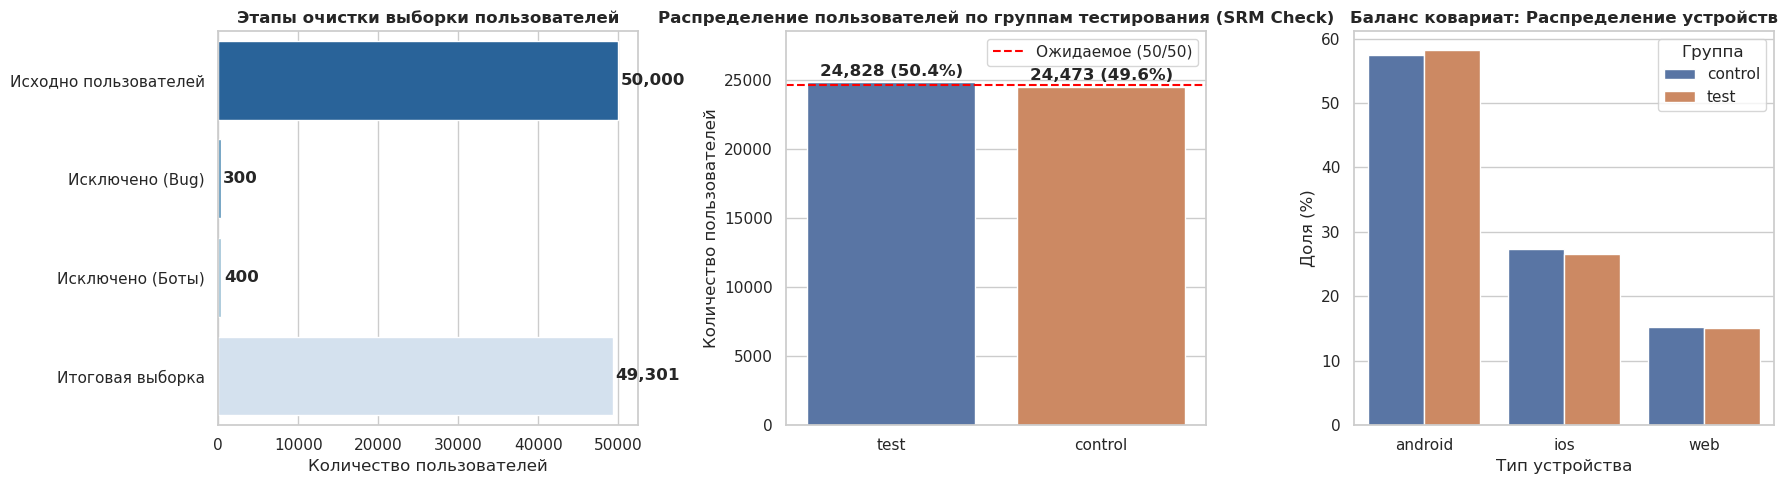

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['#4C72B0', '#DD8452']

cleaning_df = pd.DataFrame(
    {
        'stage': [
            'Исходно пользователей',
            'Исключено (Bug)',
            'Исключено (Боты)',
            'Итоговая выборка',
        ],
        'count': [
            len(users),
            len(buggy_users),
            len(bot_users),
            len(exp_clean),
        ],
    }
)

sns.barplot(
    data=cleaning_df,
    x='count',
    y='stage',
    ax=axes[0],
    palette='Blues_r',
    hue='stage',
    legend=False,
)
axes[0].set_title('Этапы очистки выборки пользователей', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Количество пользователей')
axes[0].set_ylabel('')

for i, v in enumerate(cleaning_df['count']):
    axes[0].text(v + 300, i, f'{v:,}', va='center', fontweight='bold')


group_counts = (
    exp_clean['experiment_group']
    .value_counts()
    .reset_index(name='count')
    .rename(columns={'index': 'experiment_group'})
)

sns.barplot(
    data=group_counts,
    x='experiment_group',
    y='count',
    ax=axes[1],
    palette=colors,
    hue='experiment_group',
    legend=False,
)
axes[1].axhline(y=len(exp_clean) / 2, color='red', linestyle='--', label='Ожидаемое (50/50)')
axes[1].set_title('Распределение пользователей по группам тестирования (SRM Check)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Количество пользователей')
axes[1].set_ylim(0, group_counts['count'].max() * 1.15)

for i, row in group_counts.iterrows():
    count = row['count']
    pct = count / len(exp_clean)
    axes[1].text(
        i,
        count + 500,
        f'{count:,} ({pct:.1%})',
        ha='center',
        fontweight='bold',
    )
axes[1].legend()

merged_df = exp_clean.merge(users, on='user_id')
device_bal = (
    pd.crosstab(
        merged_df['device'],
        merged_df['experiment_group'],
        normalize='columns',
    )
    * 100
)

device_bal_melted = device_bal.reset_index().melt(
    id_vars='device', var_name='experiment_group', value_name='pct'
)

sns.barplot(
    data=device_bal_melted,
    x='device',
    y='pct',
    hue='experiment_group',
    ax=axes[2],
    palette=colors,
)
axes[2].set_title(
    'Баланс ковариат: Распределение устройств', fontsize=12, fontweight='bold'
)
axes[2].set_ylabel('Доля (%)')
axes[2].set_xlabel('Тип устройства')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(title='Группа')

plt.tight_layout()
plt.show()

### 1.7 Итоговая сводка проблем и подход к обработке

| № | Проблема | Масштаб | Решение |
|---|----------|---------|---------|
| 1 | Contamination групп (`assignment_service_bug`) | 300 пользователей (0.6%) | Исключены из анализа |
| 2 | Пропуски `delivery_fee_rub` | 303 заказа (4.09%) | Заполнены медианой по `category` и `region` |
| 3 | Дубли событий показа (`is_duplicate_event`) | 3,193 записи (0.30%) | Отфильтрованы в `impressions_clean` |
| 4 | Активность ботов (`is_bot_candidate`) | 399 пользователей (0.80%) | Исключены из анализа |

## 2. EDA 

In [25]:
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["font.size"] = 10

### 2.1 Структура аудитории

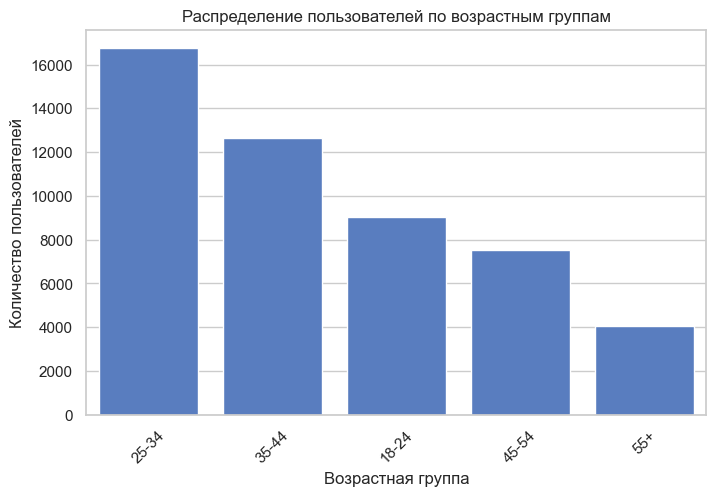

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(data=users, x="age_group", order=users["age_group"].value_counts().index)

plt.title("Распределение пользователей по возрастным группам")
plt.xlabel("Возрастная группа")
plt.ylabel("Количество пользователей")
plt.xticks(rotation=45)

plt.show()

is_premium
0    83.49
1    16.51
Name: proportion, dtype: float64

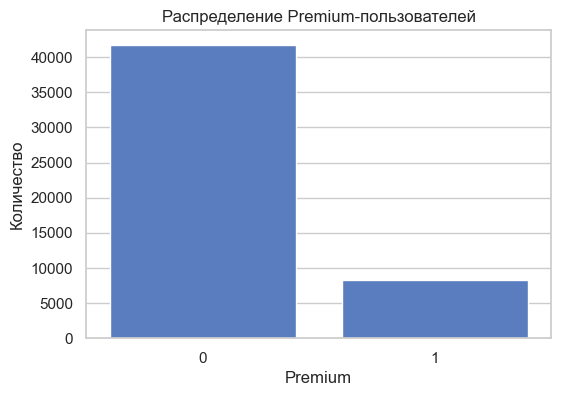

In [27]:
premium_share = ( users["is_premium"].value_counts(normalize=True)* 100)

display(premium_share.round(2))

plt.figure(figsize=(6,4))

sns.countplot(data=users, x="is_premium")

plt.title("Распределение Premium-пользователей")
plt.xlabel("Premium")
plt.ylabel("Количество")

plt.show()

### 2.2. Распределение устройств

device
android    57.79
ios        26.95
web        15.27
Name: count, dtype: float64

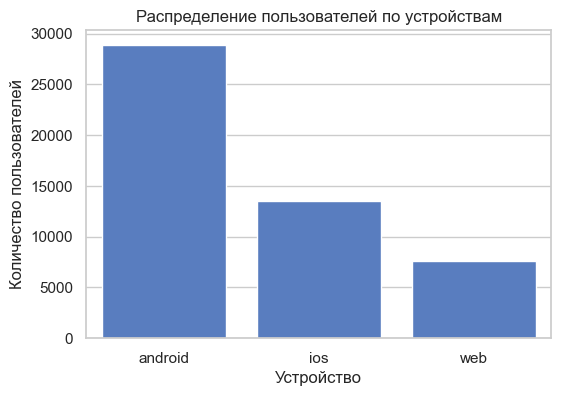

In [28]:
device_dist = users["device"].value_counts()

display((device_dist / device_dist.sum() * 100).round(2))

plt.figure(figsize=(6, 4))

sns.countplot(data=users, x="device", order=device_dist.index)

plt.title("Распределение пользователей по устройствам")
plt.xlabel("Устройство")
plt.ylabel("Количество пользователей")

plt.show()

### 2.3. Распределение источников привлечения пользователей

traffic_source
organic      42.26
paid_ads     19.17
push         11.88
direct       11.75
email         7.95
affiliate     6.99
Name: count, dtype: float64

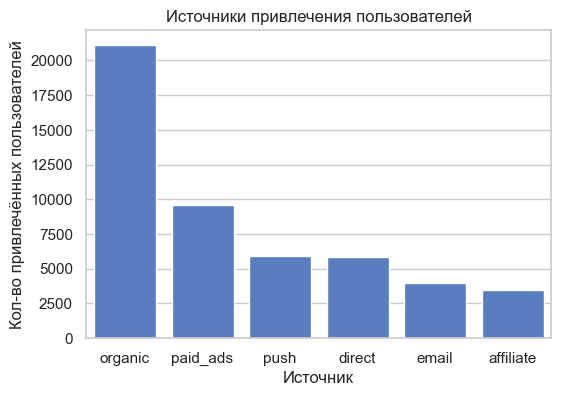

In [29]:
traffic_dist = users["traffic_source"].value_counts()

display((traffic_dist / traffic_dist.sum() * 100).round(2))

plt.figure(figsize=(6,4))

sns.countplot(data=users, x='traffic_source', order=traffic_dist.index)

plt.title("Источники привлечения пользователей")
plt.xlabel("Источник")
plt.ylabel("Кол-во привлечённых пользователей")

plt.show()

### 2.4. Региональная структура

region
Central Russia      10957
Moscow               8963
Volga                8480
Siberia              6004
Ural                 5082
South                4575
Saint Petersburg     4482
Far East             1457
Name: count, dtype: int64

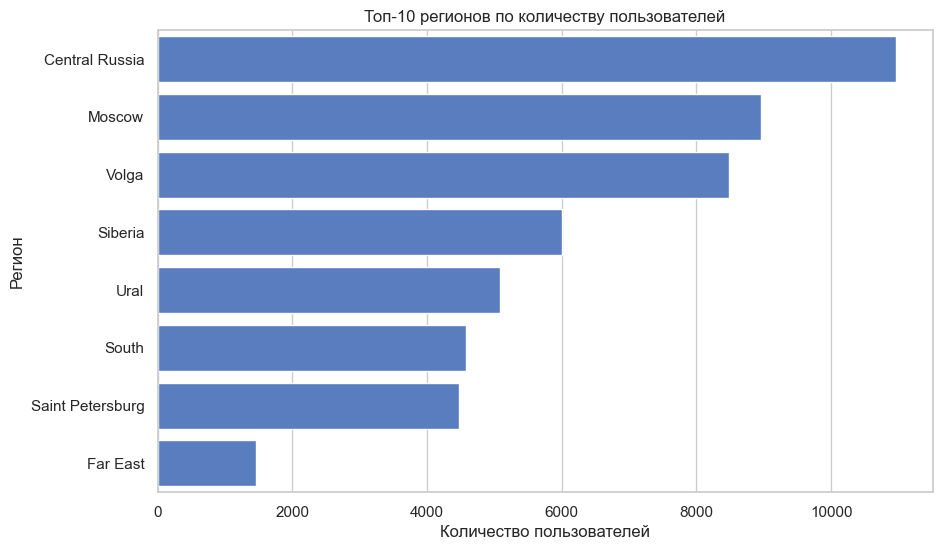

In [30]:
region_dist = users["region"].value_counts()

display(region_dist)

plt.figure(figsize=(10,6))

sns.barplot(
    x=region_dist.head(10).values,
    y=region_dist.head(10).index
)

plt.title("Топ-10 регионов по количеству пользователей")
plt.xlabel("Количество пользователей")
plt.ylabel("Регион")

plt.show()

### 2.5. Активность пользователей

count    50000.000000
mean         3.294780
std          2.168488
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         32.000000
dtype: float64

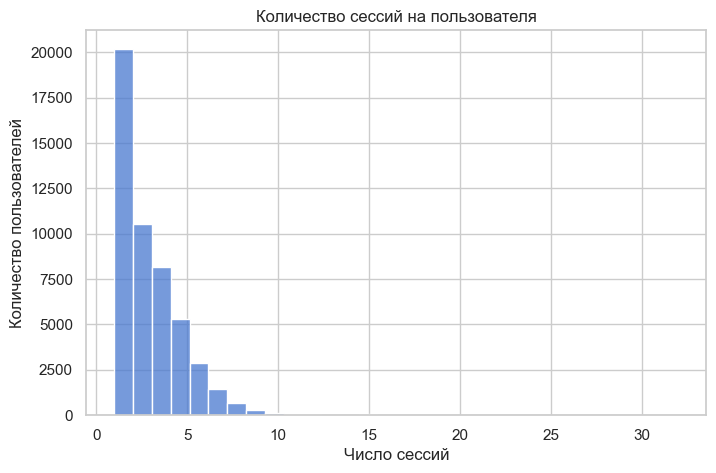

In [31]:
sessions_per_user = (sessions.groupby("user_id").size())

display(sessions_per_user.describe())

plt.figure(figsize=(8,5))

sns.histplot(sessions_per_user, bins=30)

plt.title("Количество сессий на пользователя")
plt.xlabel("Число сессий")
plt.ylabel("Количество пользователей")

plt.show()

count    164739.000000
mean          4.908288
std           4.206844
min           0.200000
25%           2.433333
50%           3.800000
75%           6.000000
max         120.000000
Name: session_duration_min, dtype: float64

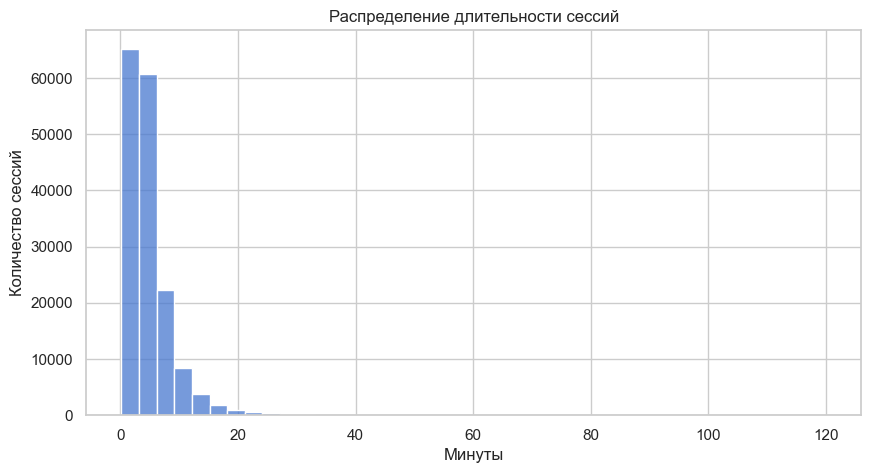

In [32]:
sessions["session_duration_min"] = (sessions["session_duration_sec"] / 60)

display(sessions["session_duration_min"].describe())

plt.figure(figsize=(10,5))

sns.histplot(
    sessions["session_duration_min"],
    bins=40
)

plt.title("Распределение длительности сессий")
plt.xlabel("Минуты")
plt.ylabel("Количество сессий")

plt.show()

## 2.6. Структура заказов

category
Fashion        1249
Electronics    1098
Home           1003
Beauty          923
FMCG            655
Kids            611
Sports          556
Pet             456
Books           429
Auto            427
Name: count, dtype: int64

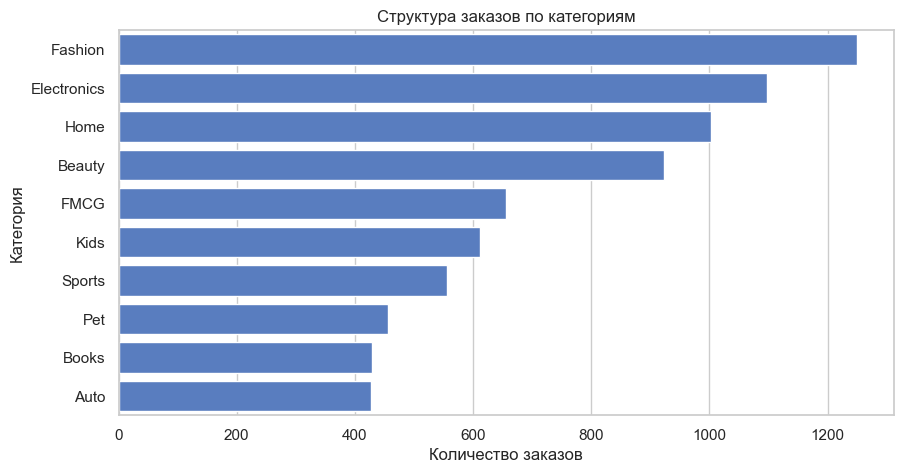

In [33]:
category_orders = (
    orders["category"]
    .value_counts()
)

display(category_orders)

plt.figure(figsize=(10,5))

sns.countplot(
    data=orders,
    y="category",
    order=orders["category"].value_counts().index
)

plt.title("Структура заказов по категориям")
plt.xlabel("Количество заказов")
plt.ylabel("Категория")

plt.show()

## Итоговые выводы EDA

В ходе исследовательского анализа были изучены основные характеристики аудитории маркетплейса и её поведение.

Основные наблюдения:

- Наиболее многочисленной возрастной группой являются пользователи 25–34 лет, далее следуют группы 35–44 и 18–24 года. Это говорит о том, что основная аудитория платформы представлена пользователями трудоспособного возраста.

- Большинство пользователей не имеют Premium-подписки (около 83%), тогда как доля Premium-аудитории составляет около 17%. Следовательно, результаты дальнейшего анализа будут в основном отражать поведение обычных пользователей.

- Основным устройством для взаимодействия с платформой является Android, на втором месте находятся устройства iOS, а web-версия используется заметно реже. Это свидетельствует о преобладании мобильного трафика.

- Наиболее значимым источником привлечения пользователей является органический трафик. Платные каналы и push-уведомления также вносят существенный вклад, однако их аудитория заметно меньше.

- Пользователи распределены по регионам неравномерно. Наибольшее количество пользователей сосредоточено в Центральной России и Москве, что указывает на высокую концентрацию аудитории в крупнейших экономических центрах.

- Анализ заказов показал, что наиболее популярными категориями товаров являются `Fashion`, `Electronics` и `Home`. Эти категории формируют значительную часть покупательской активности на платформе.

Таким образом, аудитория маркетплейса характеризуется преобладанием мобильных пользователей среднего возраста, привлечённых преимущественно через органические каналы. Пользовательская база сосредоточена в крупных регионах страны, а наибольший спрос наблюдается в категориях `Fashion` и `Electronics`. Полученные результаты позволяют перейти к более детальному анализу пользовательской активности и эффективности рекомендательной системы.